In [ ]:
import os
import shutil
import pandas as pd
import numpy as np
from PIL import Image, ImageStat
from tqdm import tqdm

DATASET_ROOT = "/home/datasets/wikiart"  # canvia-ho si cal

OUTPUT_DIR = "results/analysis/suspicious_images"
CSV_PATH = "results/analysis/suspicious_images_report.csv"

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

MIN_WIDTH = 100
MIN_HEIGHT = 100

MAX_ASPECT_RATIO = 3.0
MIN_ASPECT_RATIO = 1 / 3

# Llindars simples per detectar imatges rares
VERY_DARK_MEAN = 20
VERY_BRIGHT_MEAN = 235
LOW_STD_THRESHOLD = 8

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CSV_PATH), exist_ok=True)


def is_image_file(filename):
    return filename.lower().endswith(VALID_EXTENSIONS)


records = []

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_dir = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_dir):
        continue

    for filename in tqdm(sorted(os.listdir(class_dir)), desc=class_name):
        if not is_image_file(filename):
            continue

        path = os.path.join(class_dir, filename)

        record = {
            "path": path,
            "class_name": class_name,
            "filename": filename,
            "can_open": True,
            "width": None,
            "height": None,
            "aspect_ratio": None,
            "mean_brightness": None,
            "std_brightness": None,
            "reason": [],
            "suspicion_score": 0,
        }

        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
                width, height = img.size

                gray = img.convert("L")
                stat = ImageStat.Stat(gray)
                mean_brightness = stat.mean[0]
                std_brightness = stat.stddev[0]

        except Exception as e:
            record["can_open"] = False
            record["reason"].append(f"cannot_open:{type(e).__name__}")
            record["suspicion_score"] += 100
            records.append(record)
            continue

        aspect_ratio = width / height

        record["width"] = width
        record["height"] = height
        record["aspect_ratio"] = aspect_ratio
        record["mean_brightness"] = mean_brightness
        record["std_brightness"] = std_brightness

        if width < MIN_WIDTH or height < MIN_HEIGHT:
            record["reason"].append("too_small")
            record["suspicion_score"] += 50

        if aspect_ratio > MAX_ASPECT_RATIO or aspect_ratio < MIN_ASPECT_RATIO:
            record["reason"].append("extreme_aspect_ratio")
            record["suspicion_score"] += 40

        if mean_brightness < VERY_DARK_MEAN:
            record["reason"].append("very_dark")
            record["suspicion_score"] += 20

        if mean_brightness > VERY_BRIGHT_MEAN:
            record["reason"].append("very_bright")
            record["suspicion_score"] += 20

        if std_brightness < LOW_STD_THRESHOLD:
            record["reason"].append("almost_uniform")
            record["suspicion_score"] += 20

        record["reason"] = ";".join(record["reason"])

        records.append(record)

df = pd.DataFrame(records)
df = df.sort_values("suspicion_score", ascending=False)

df.to_csv(CSV_PATH, index=False)

df.head(30)

Ukiyo_e: 100%|██████████| 1167/1167 [00:41<00:00, 27.98it/s]


,path,class_name,filename,can_open,width,height,aspect_ratio,mean_brightness,std_brightness,reason,suspicion_score
41094,/home/datasets/wikiart/Minimalism/frank-stella...,Minimalism,frank-stella_del-mar-from-race-track-series-19...,True,5440,1382,3.936324,243.799092,5.220779,extreme_aspect_ratio;very_bright;almost_uniform,80
40740,/home/datasets/wikiart/Minimalism/andrei-cader...,Minimalism,andrei-cadere_round-wooden-bar-in-red-blue-ora...,True,1382,4624,0.298875,237.947211,33.111598,extreme_aspect_ratio;very_bright,60
11678,/home/datasets/wikiart/Color_Field_Painting/an...,Color_Field_Painting,anne-truitt_one-may-1976.jpg,True,15754,1382,11.399421,156.681415,4.728991,extreme_aspect_ratio;almost_uniform,60
40748,/home/datasets/wikiart/Minimalism/andrei-cader...,Minimalism,andrei-cadere_untitled-polychrome-bar-1970.jpg,True,4275,1381,3.095583,243.558044,27.331909,extreme_aspect_ratio;very_bright,60
41162,/home/datasets/wikiart/Minimalism/giovanni-ans...,Minimalism,giovanni-anselmo_linea-terra-1970.jpg,True,4328,1382,3.131693,219.894206,25.558523,extreme_aspect_ratio,40
11755,/home/datasets/wikiart/Color_Field_Painting/ba...,Color_Field_Painting,barnett-newman_the-voice-1950.jpg,True,1530,1382,1.107091,235.360756,4.886528,very_bright;almost_uniform,40
11756,/home/datasets/wikiart/Color_Field_Painting/ba...,Color_Field_Painting,barnett-newman_the-wild-1950.jpg,True,1382,4766,0.289971,217.390599,31.620765,extreme_aspect_ratio,40
11760,/home/datasets/wikiart/Color_Field_Painting/ba...,Color_Field_Painting,barnett-newman_treble-1960.jpg,True,1382,4487,0.308001,130.724569,57.959079,extreme_aspect_ratio,40
11765,/home/datasets/wikiart/Color_Field_Painting/ba...,Color_Field_Painting,barnett-newman_untitled-3-1949.jpg,True,1381,4922,0.280577,71.381957,14.901130,extreme_aspect_ratio,40
11767,/home/datasets/wikiart/Color_Field_Painting/ba...,Color_Field_Painting,barnett-newman_untitled-i-1950.jpg,True,1382,8189,0.168763,76.715014,29.518539,extreme_aspect_ratio,40


In [ ]:
print("Total imatges:", len(df))
print("No es poden obrir:", (~df["can_open"]).sum())
print("Sospitoses:", (df["suspicion_score"] > 0).sum())

df[df["suspicion_score"] > 0]["reason"].value_counts().head(20)

Total imatges: 81444
No es poden obrir: 0
Sospitoses: 629


reason
extreme_aspect_ratio                               315
almost_uniform                                     157
very_bright                                        114
very_dark                                           22
very_bright;almost_uniform                          15
very_dark;almost_uniform                             2
extreme_aspect_ratio;very_bright                     2
extreme_aspect_ratio;very_bright;almost_uniform      1
extreme_aspect_ratio;almost_uniform                  1
Name: count, dtype: int64

In [ ]:
TOP_N = 30

suspicious = df[
    (df["suspicion_score"] > 0) &
    (df["can_open"] == True)
].head(TOP_N)

for i, row in suspicious.iterrows():
    src = row["path"]
    class_name = row["class_name"]
    reason = row["reason"].replace(";", "_")
    score = row["suspicion_score"]

    safe_filename = f"score-{score}_class-{class_name}_reason-{reason}_{os.path.basename(src)}"
    dst = os.path.join(OUTPUT_DIR, safe_filename)

    try:
        shutil.copy2(src, dst)
    except Exception as e:
        print(f"No s'ha pogut copiar {src}: {e}")

print(f"Copiades {len(suspicious)} imatges sospitoses a:")
print(OUTPUT_DIR)

Copiades 30 imatges sospitoses a:
results/analysis/suspicious_images


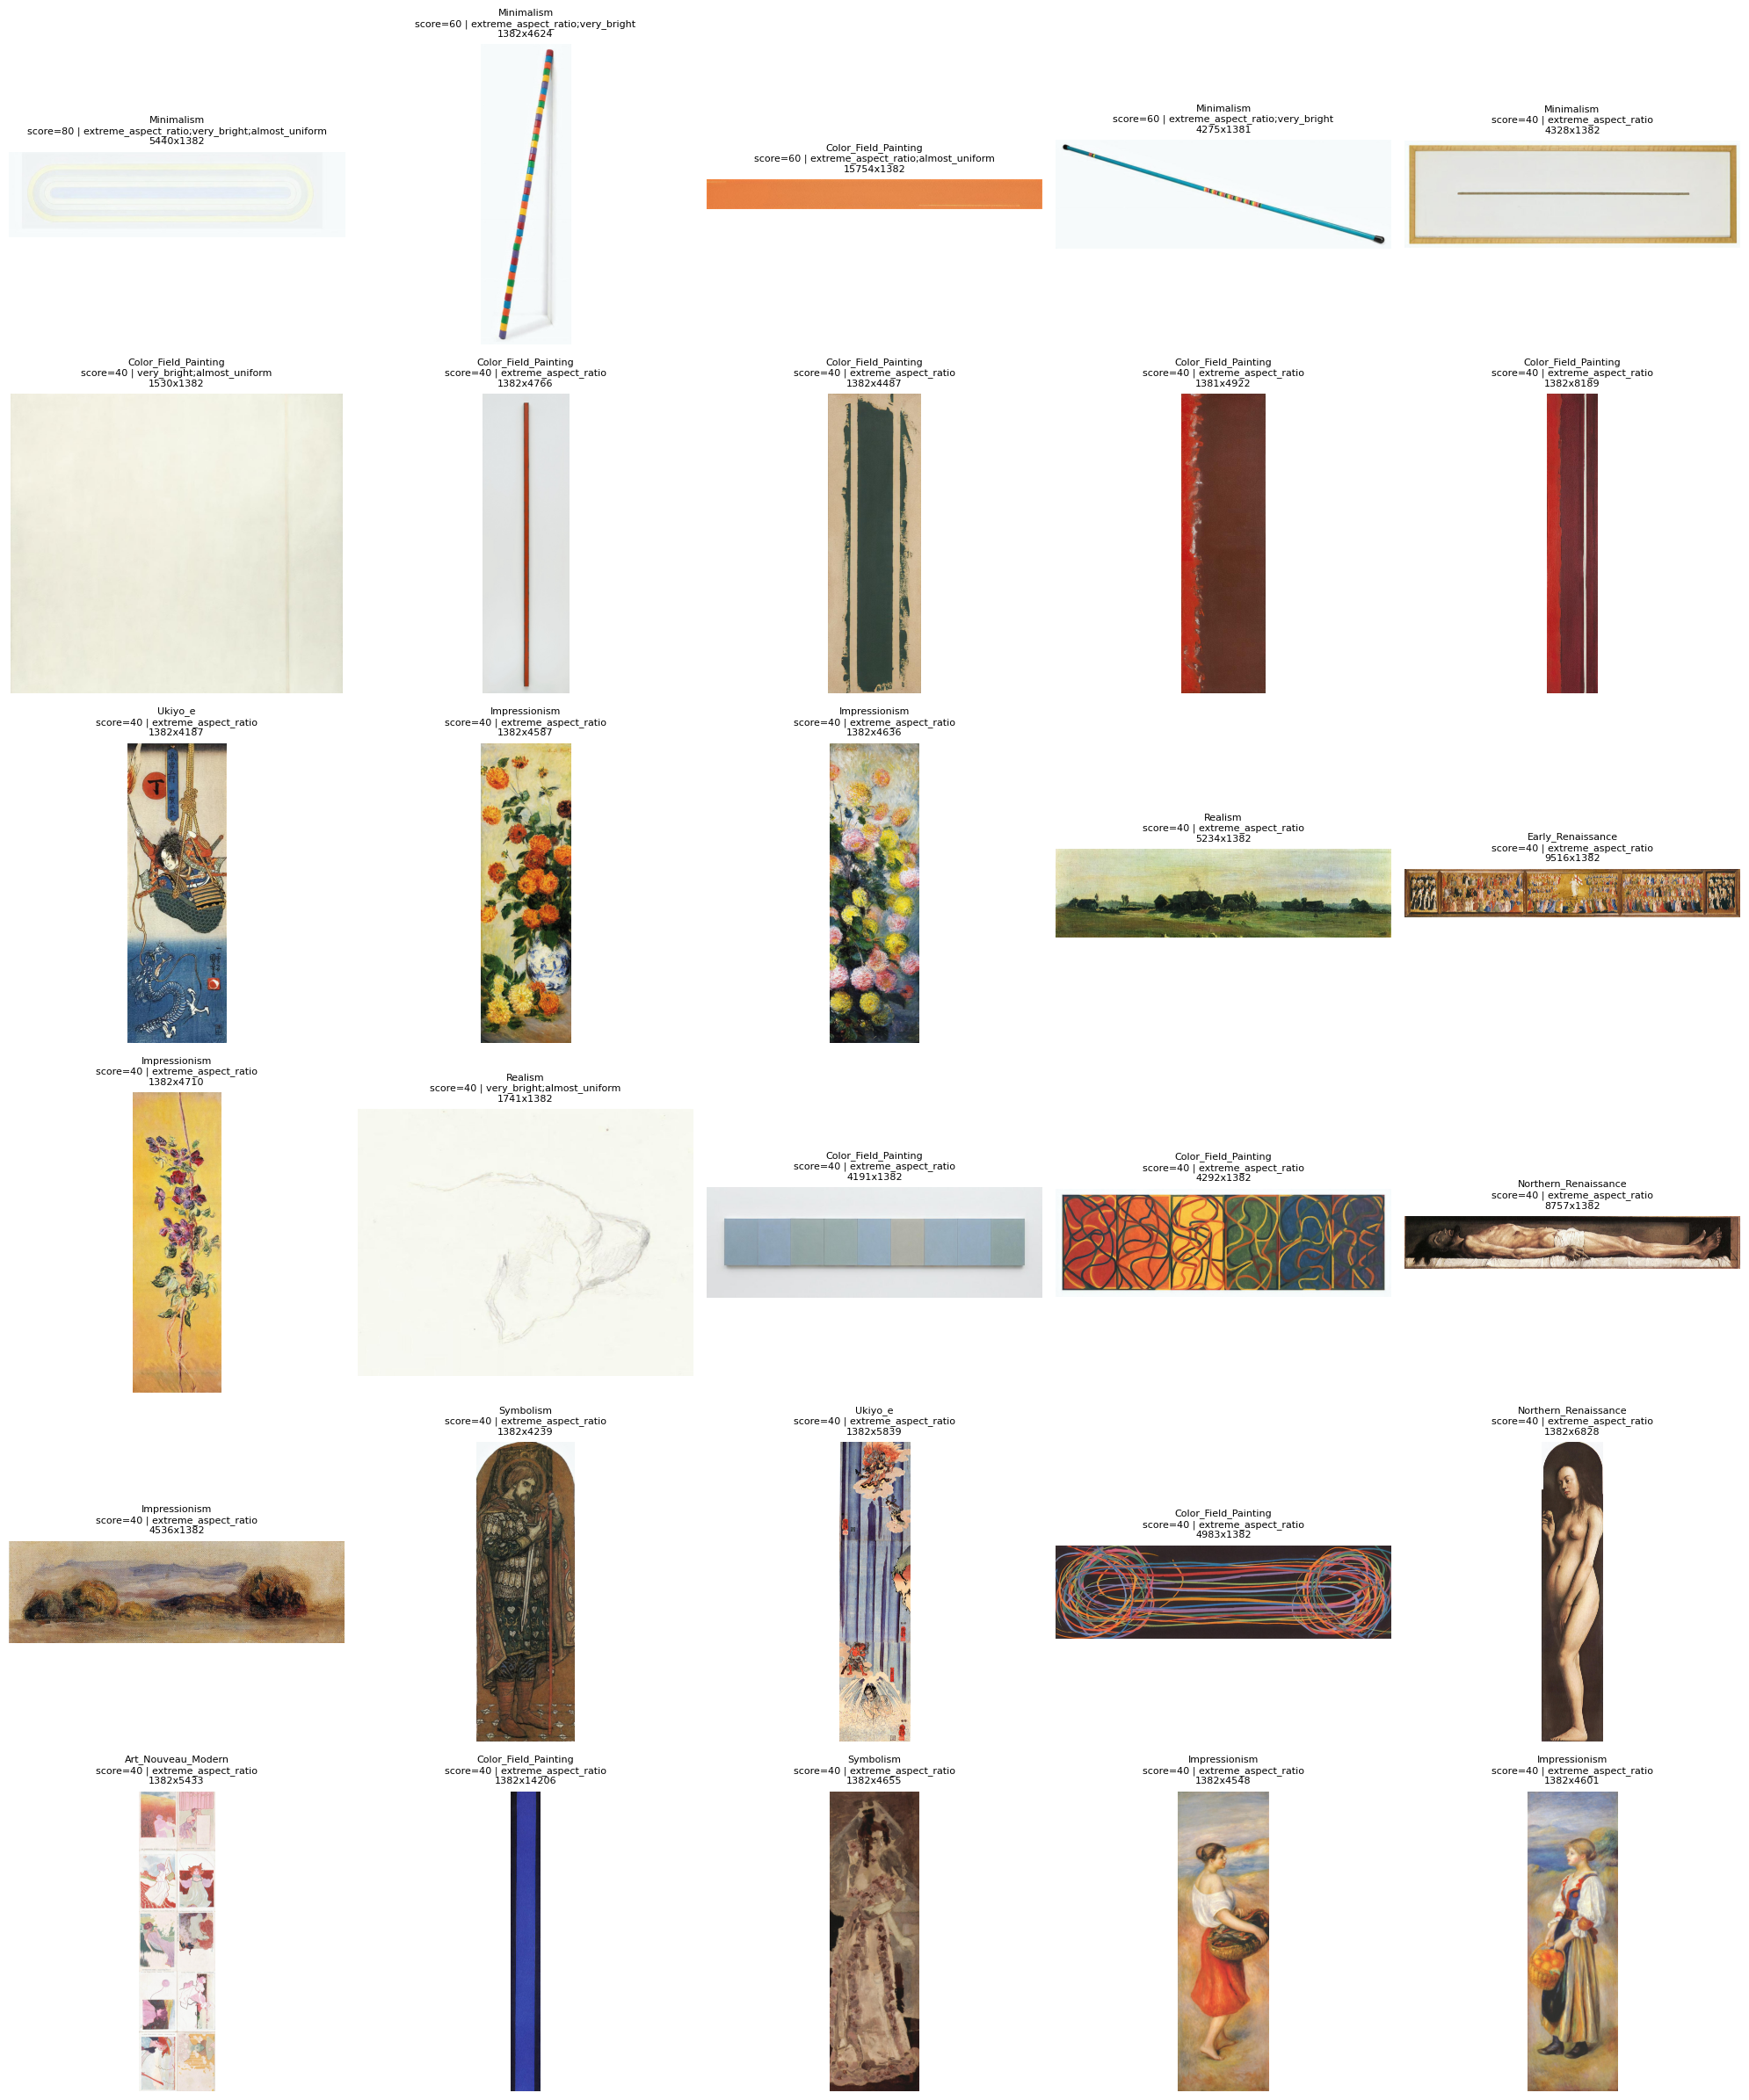

In [ ]:
import matplotlib.pyplot as plt
import math

def show_suspicious_images(df_suspicious, max_images=30):
    subset = df_suspicious.head(max_images)

    cols = 5
    rows = math.ceil(len(subset) / cols)

    plt.figure(figsize=(cols * 4, rows * 4))

    for plot_idx, (_, row) in enumerate(subset.iterrows(), start=1):
        path = row["path"]

        plt.subplot(rows, cols, plot_idx)

        try:
            img = Image.open(path).convert("RGB")
            plt.imshow(img)
            title = (
                f"{row['class_name']}\n"
                f"score={row['suspicion_score']} | {row['reason']}\n"
                f"{row['width']}x{row['height']}"
            )
            plt.title(title, fontsize=8)
            plt.axis("off")
        except Exception as e:
            plt.text(0.5, 0.5, f"No es pot obrir\n{type(e).__name__}", ha="center")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


show_suspicious_images(suspicious, max_images=30)